In [1]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import glob
import random

In [2]:
# list all image paths
image_dir = "../../../data/image_resize/images/"
image_files = glob.glob(image_dir + "*")
print(len(image_files))
print(image_files[:5])

60575
['../../../data/image_resize/images/45df1fe3293b.jpg', '../../../data/image_resize/images/b2ab3b743d4e.jpg', '../../../data/image_resize/images/51d3b1a6baf3.jpg', '../../../data/image_resize/images/a9e9ce9277c1.jpg', '../../../data/image_resize/images/7f1f545fe081.jpg']


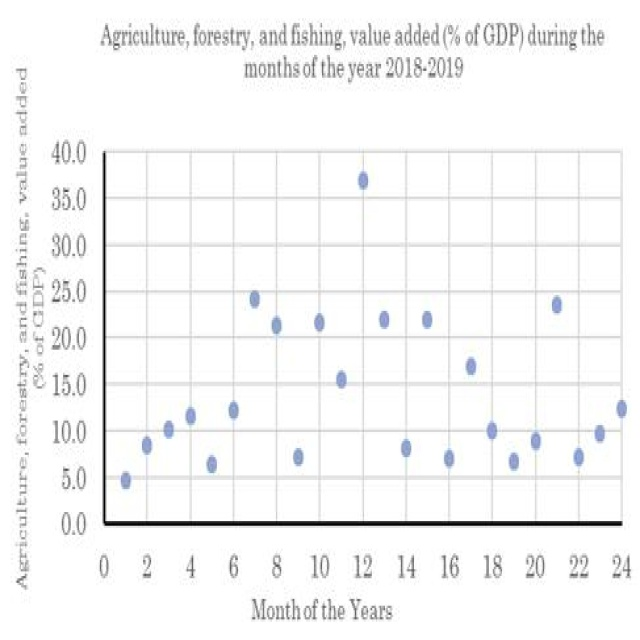

In [3]:
image_path = image_files[0]
original_image = Image.open(image_path).convert("RGB")
original_image

(224, 224)


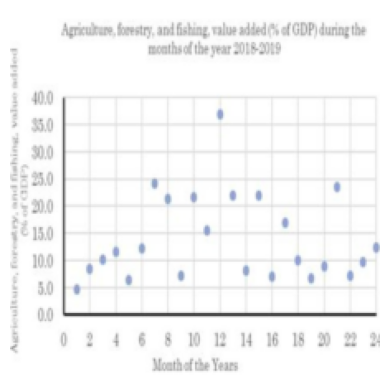

In [4]:
# Random Resized Crop

# first crop almost all image as output (set the least cropped area is 80% and the most is 100%), resize to 224
random_resized_crop_transform=transforms.RandomResizedCrop(224, scale=(0.8, 1.0))
image1 = random_resized_crop_transform(original_image)
print(image1.size)
plt.imshow(image1)
# plt.title("Random Resized Crop")
plt.axis("off")
plt.show()

(224, 224)


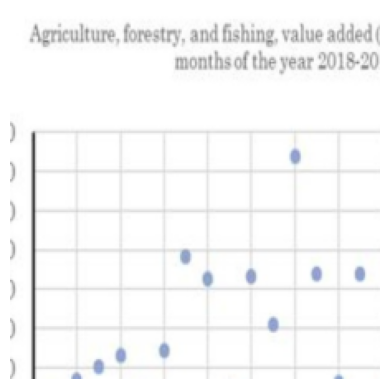

In [5]:
# Random Resized Crop

# first crop almost all image as output (set the least cropped area is 30% and the most is 100%), resize to 224
random_resized_crop_transform=transforms.RandomResizedCrop(224, scale=(0.2, 0.7))
image1 = random_resized_crop_transform(original_image)
print(image1.size)
plt.imshow(image1)
# plt.title("Random Resized Crop")
plt.axis("off")
plt.show()

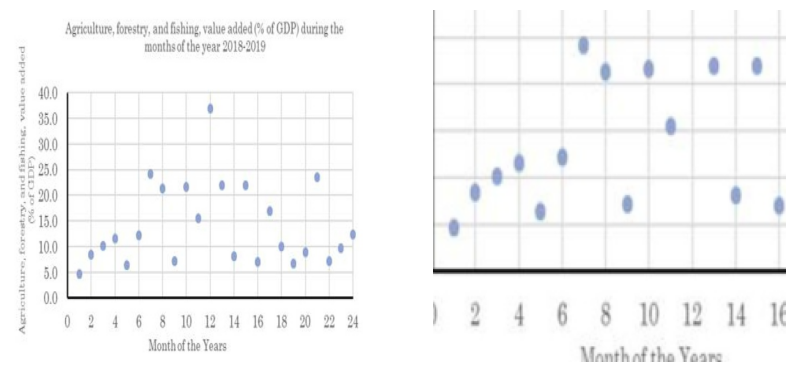

In [6]:
# Random Resized crop (cover center point in original image in crop frame)

# I want to crop the image but ensure that the cropped image always include the center point in the original image
# because images here are graphs, the main content is centered
# this apporach make sure that i could get a part of main body all the time.

W, H = original_image.size

# calculate the center point in the original image
center_x, center_y = W // 2, H // 2

# 1. Randomly select crop box size
scale_min, scale_max = 0.3, 0.6  # allowable crop range (0.3 - 0.6)
crop_ratio = random.uniform(scale_min, scale_max)  # generate the random ratio
crop_W, crop_H = int(W * crop_ratio), int(H * crop_ratio)  # calculate the cropped height and width

# 2. make sure the crop frame cloud cover the original image's center point
left_min = max(0, center_x - crop_W) 
top_min = max(0, center_y - crop_H) 

left_max = min(W - crop_W, center_x) 
top_max = min(H - crop_H, center_y) 

# 3. random select the frame coordinates
left = random.randint(left_min, left_max)
top = random.randint(top_min, top_max)
right = left + crop_W
bottom = top + crop_H

cropped_image = original_image.crop((left, top, right, bottom))

# resizing 224x224
final_transform = transforms.Compose([
    transforms.Resize((224, 224))
])
resized_image = final_transform(cropped_image)



fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
# axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(resized_image)
# axes[1].set_title("Random Crop (Ensuring Center) + Resize 224x224")
axes[1].axis("off")

plt.show()

(640, 640)


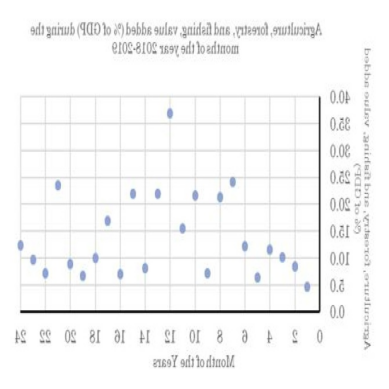

In [7]:
# Random Horizontal Flip

transform2 = transforms.RandomHorizontalFlip(p=1.0)  # 100% Flip
image2 = transform2(original_image)

print(image2.size)
plt.imshow(image2)
plt.axis("off")
plt.show()

(640, 640)


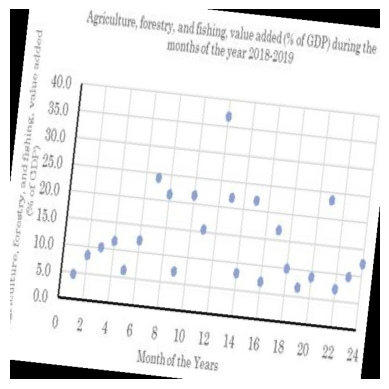

In [8]:
# Random Rotation, ±10°

transform3 = transforms.RandomRotation(degrees=10) # 10 degree retate
image3 = transform3(original_image)

print(image3.size)
plt.imshow(image3)
plt.axis("off")
plt.show()

(640, 640)


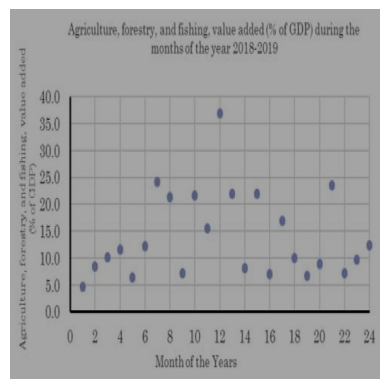

In [9]:
# color jittering

transform4 = transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)
image4 = transform4(original_image)

print(image4.size)
plt.imshow(image4)
plt.axis("off")
plt.show()

(640, 640)


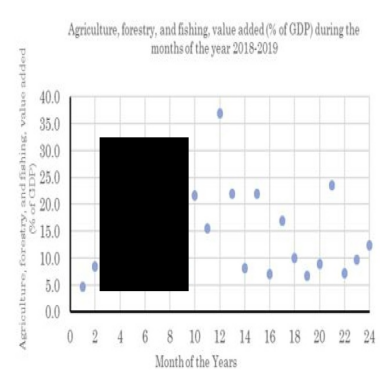

In [10]:
# Random Erasing

transform5 = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomErasing(p=1.0, scale=(0.02, 0.33), value=0),
    transforms.ToPILImage()
])
image5 = transform5(original_image)

print(image5.size)
plt.imshow(image5)
plt.axis("off")
plt.show()

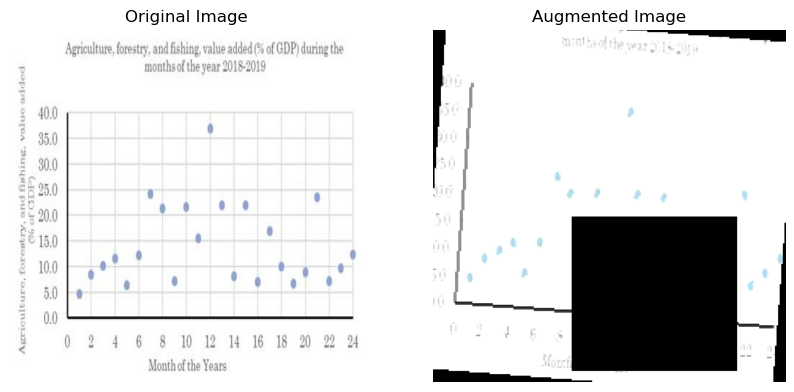

In [11]:
image_path = image_files[0]
original_image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=10),  
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),  
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), value=0),
])


augmented_image = transform(original_image)


def tensor_to_image(tensor):
    image = tensor.numpy().transpose(1, 2, 0)  
    image = np.clip(image, 0, 1) 
    return image


fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(tensor_to_image(augmented_image))
axes[1].set_title("Augmented Image")
axes[1].axis("off")

plt.show()

(224, 224)


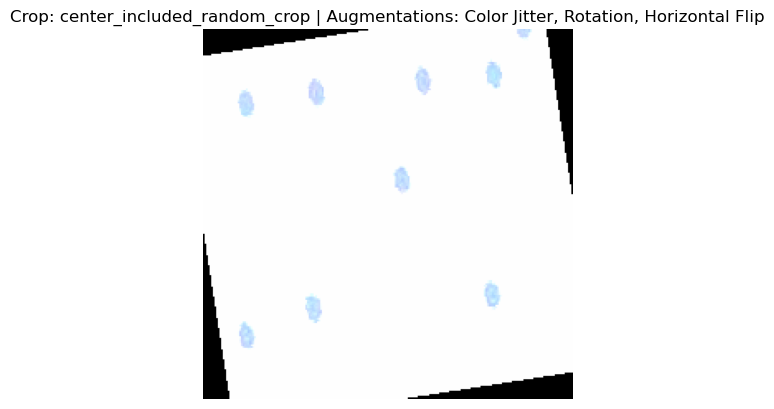

In [ ]:
# grab the size of original image
W, H = original_image.size
center_x, center_y = W // 2, H // 2  # calculate the center point of the original image

# two crop ways
def random_resized_crop(img):
    """
    crop the image
    """
    crop_transform = transforms.RandomResizedCrop(224, scale=(0.3, 1.0))
    return crop_transform(img)

def center_included_random_crop(img):
    """
    Ensure random cropping within the center point
    """
    scale_min, scale_max = 0.3, 0.6  # allowable crop ratio
    crop_ratio = random.uniform(scale_min, scale_max)  # generate the crop ratio
    crop_W, crop_H = int(W * crop_ratio), int(H * crop_ratio)

    # make sure the original image's center point in the crop frame
    left_min = max(0, center_x - crop_W)
    top_min = max(0, center_y - crop_H)
    left_max = min(W - crop_W, center_x)
    top_max = min(H - crop_H, center_y)

    # random select the crop frame's coordinates
    left = random.randint(left_min, left_max)
    top = random.randint(top_min, top_max)
    right = left + crop_W
    bottom = top + crop_H

    # resizing
    cropped_img = img.crop((left, top, right, bottom))
    resize_transform = transforms.Resize((224, 224))
    return resize_transform(cropped_img)

# define other augmentations
augmentation_transforms = {
    "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
    "Rotation": transforms.RandomRotation(degrees=10),
    "Color Jitter": transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    "Random Erasing": transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomErasing(p=1.0, scale=(0.02, 0.33), value=0),
        transforms.ToPILImage()
    ])
}

# random choose a crop apporoach
crop_methods = [random_resized_crop, center_included_random_crop]
chosen_crop_method = random.choice(crop_methods)

augmented_image = chosen_crop_method(original_image)


# random choose other augmentation methods
num_augmentations = random.randint(1, len(augmentation_transforms))
chosen_augmentations = random.sample(list(augmentation_transforms.keys()), num_augmentations)

# apply augmentations
for augmentation in chosen_augmentations:
    augmented_image = augmentation_transforms[augmentation](augmented_image)

print(augmented_image.size)
# show the augmentated image
plt.imshow(augmented_image)
crop_name = chosen_crop_method.__name__ if chosen_crop_method else "No Crop"
plt.title(f"Crop: {crop_name} | Augmentations: {', '.join(chosen_augmentations)}")
plt.axis("off")
plt.show()